In [11]:
import pandas as pd
import torch
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from rouge_score import rouge_scorer
import json
import matplotlib.pyplot as plt

print("✅ Imports réussis")

✅ Imports réussis


In [12]:
df = pd.read_csv('../datasets/summary_training_data.csv')
print(f"📊 Dataset chargé : {df.shape}")
print(f"\n📈 Distribution des catégories :")
print(df['category'].value_counts())
print(f"\n🔍 Aperçu :")
df.head()

📊 Dataset chargé : (100, 5)

📈 Distribution des catégories :
category
Hardware    29
Printer     27
Software    24
Network     20
Name: count, dtype: int64

🔍 Aperçu :


,id,description,summary,category,urgency
0,REC0001,Écran noir au démarrage de mon PC HP LaserJet ...,"Problème technique sur Hardware, diagnostic né...",Hardware,High
1,REC0002,Problème de connexion WiFi sur mon Pavilion. L...,"Problème de connexion réseau, coupures fréquen...",Software,Low
2,REC0003,Problème de WiFi instable sur mon imprimante P...,"Problème de connexion réseau, coupures fréquen...",Printer,High
3,REC0004,Mon imprimante LaserJet Pro ne s'allume plus d...,"Imprimante ne s'allume plus, voyant d'alimenta...",Hardware,Low
4,REC0005,Problème de WiFi instable sur mon ordinateur p...,"Problème de connexion réseau, coupures fréquen...",Network,Low


✅ Train: 80 | Test: 20


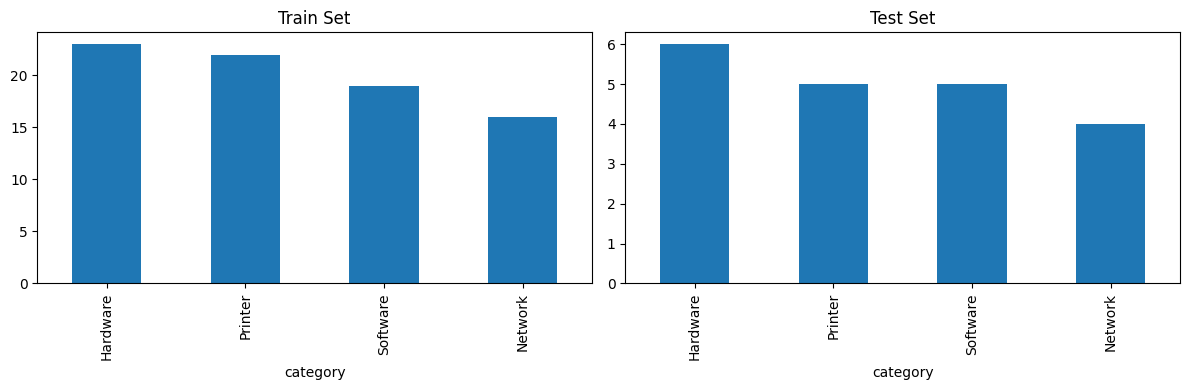

In [13]:
# Cellule 3 : Préparation des données
df['input_text'] = 'summarize: ' + df['description']
df['target_text'] = df['summary']

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])
print(f"✅ Train: {len(train_df)} | Test: {len(test_df)}")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['category'].value_counts().plot(kind='bar', ax=axes[0], title='Train Set')
test_df['category'].value_counts().plot(kind='bar', ax=axes[1], title='Test Set')
plt.tight_layout()
plt.show()

In [14]:
# Cellule 4 : Chargement du modèle
model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)
print(f"✅ Modèle {model_name} chargé")
print(f"📊 Paramètres : {model.num_parameters():,}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

✅ Modèle t5-small chargé
📊 Paramètres : 60,506,624


In [15]:
# Cellule 5 : Tokenization
train_dataset = Dataset.from_pandas(train_df[['input_text', 'target_text']])
test_dataset = Dataset.from_pandas(test_df[['input_text', 'target_text']])

def preprocess_function(examples):
    inputs = examples['input_text']
    targets = examples['target_text']
    
    model_inputs = tokenizer(
        inputs, 
        max_length=512, 
        truncation=True, 
        padding='max_length'
    )
    
    labels = tokenizer(
        targets, 
        max_length=128, 
        truncation=True, 
        padding='max_length'
    )
    
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)
print("✅ Tokenization terminée")

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

✅ Tokenization terminée


In [26]:
training_args = Seq2SeqTrainingArguments(
    output_dir='../results/summarizer',

    num_train_epochs=5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    predict_with_generate=True,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_dir="../logs",

    logging_steps=50,

    save_total_limit=2,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

print("✅ Configuration créée")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Configuration créée


In [27]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Nettoyage des labels
    labels = np.where(
        labels < 0,
        tokenizer.pad_token_id,
        labels
    )

    decoded_preds = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    for pred, label in zip(decoded_preds, decoded_labels):

        scores = scorer.score(label, pred)

        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    return {
        "rouge1": float(np.mean(rouge1_scores)),
        "rouge2": float(np.mean(rouge2_scores)),
        "rougeL": float(np.mean(rougeL_scores))
    }

In [22]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer créé")
print(f"📊 Dataset d'entraînement : {len(train_dataset)} exemples")
print(f"📊 Dataset de test : {len(test_dataset)} exemples")

✅ Trainer créé
📊 Dataset d'entraînement : 80 exemples
📊 Dataset de test : 20 exemples


In [28]:
# ═══════════════════════════════════════════════════════════
# Cellule 8 : Entraînement du modèle
# ═══════════════════════════════════════════════════════════

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer créé")
print(f"📊 Dataset d'entraînement : {len(train_dataset)} exemples")
print(f"📊 Dataset de test : {len(test_dataset)} exemples")

print("\n" + "="*80)
print("🔥 DÉBUT DE L'ENTRAÎNEMENT")
print("="*80)

trainer.train()

print("\n" + "="*80)
print("✅ ENTRAÎNEMENT TERMINÉ")
print("="*80)

# Évaluation finale
results = trainer.evaluate()

print("\n📊 Résultats finaux :")
print(results)

✅ Trainer créé
📊 Dataset d'entraînement : 80 exemples
📊 Dataset de test : 20 exemples

🔥 DÉBUT DE L'ENTRAÎNEMENT


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,No log,4.443741,0.050556,0.033333,0.050556
2,No log,1.110892,0.025556,0.016667,0.025556
3,No log,0.495837,0.000000,0.000000,0.000000
4,No log,0.438415,0.000000,0.000000,0.000000
5,3.154628,0.432114,0.000000,0.000000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\sjlassi\projet_pfe\hp_chatbot_callbot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].
c:\Users\sjlassi\projet_pfe\hp_chatbot_callbot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ ENTRAÎNEMENT TERMINÉ


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel
3.154628,0.432114,5,0.000000,0.000000,0.000000



📊 Résultats finaux :
{'eval_loss': 0.43211355805397034, 'eval_rouge1': 0.0, 'eval_rouge2': 0.0, 'eval_rougeL': 0.0}


In [30]:
df[['description','summary']].head(10)

,description,summary
0,Écran noir au démarrage de mon PC HP LaserJet ...,"Problème technique sur Hardware, diagnostic né..."
1,Problème de connexion WiFi sur mon Pavilion. L...,"Problème de connexion réseau, coupures fréquen..."
2,Problème de WiFi instable sur mon imprimante P...,"Problème de connexion réseau, coupures fréquen..."
3,Mon imprimante LaserJet Pro ne s'allume plus d...,"Imprimante ne s'allume plus, voyant d'alimenta..."
4,Problème de WiFi instable sur mon ordinateur p...,"Problème de connexion réseau, coupures fréquen..."
5,Mon imprimante ZBook ne s'allume plus depuis i...,"Imprimante ne s'allume plus, voyant d'alimenta..."
6,Problème de scanner non fonctionnel sur mon im...,"Problème technique sur Software, diagnostic né..."
7,Écran noir au démarrage de mon PC HP EliteBook...,"Problème technique sur Printer, diagnostic néc..."
8,Mon imprimante LaserJet Pro ne s'allume plus d...,"Imprimante ne s'allume plus, voyant d'alimenta..."
9,Problème de connexion WiFi sur mon OfficeJet P...,"Problème de connexion réseau, coupures fréquen..."


In [ ]:
# ═══════════════════════════════════════════════════════════
# Cellule 9 : Évaluation finale et visualisation des résultats
# ═══════════════════════════════════════════════════════════

print("📊 Évaluation finale sur le test set...\n")
results = trainer.evaluate()

print("="*80)
print("📈 RÉSULTATS FINAUX")
print("="*80)
for key, value in results.items():
    if isinstance(value, float):
        print(f"  {key:25} : {value:.4f}")
    else:
        print(f"  {key:25} : {value}")
print("="*80)

# ═══════════════════════════════════════════════════════════
# Visualisation des métriques d'entraînement
# ═══════════════════════════════════════════════════════════

metrics_df = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Training Loss
loss_data = metrics_df[metrics_df['loss'].notna()]
if not loss_data.empty:
    axes[0, 0].plot(loss_data.index, loss_data['loss'], 'b-', linewidth=2, marker='o')
    axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

# 2. Evaluation Loss
eval_loss_data = metrics_df[metrics_df['eval_loss'].notna()]
if not eval_loss_data.empty:
    axes[0, 1].plot(eval_loss_data['epoch'], eval_loss_data['eval_loss'], 'r-', linewidth=2, marker='s')
    axes[0, 1].set_title('Evaluation Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# 3. ROUGE Scores
eval_metrics = metrics_df[metrics_df['eval_rouge1'].notna()]
if not eval_metrics.empty:
    axes[1, 0].plot(eval_metrics['epoch'], eval_metrics['eval_rouge1'], 'g-', linewidth=2, marker='o', label='ROUGE-1')
    axes[1, 0].plot(eval_metrics['epoch'], eval_metrics['eval_rouge2'], 'b-', linewidth=2, marker='s', label='ROUGE-2')
    axes[1, 0].plot(eval_metrics['epoch'], eval_metrics['eval_rougeL'], 'r-', linewidth=2, marker='^', label='ROUGE-L')
    axes[1, 0].set_title('ROUGE Scores Evolution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 4. Comparaison finale des métriques
final_metrics = {
    'ROUGE-1': results['eval_rouge1'],
    'ROUGE-2': results['eval_rouge2'],
    'ROUGE-L': results['eval_rougeL']
}
axes[1, 1].bar(final_metrics.keys(), final_metrics.values(), color=['green', 'blue', 'red'], alpha=0.7)
axes[1, 1].set_title('Final ROUGE Scores', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (metric, value) in enumerate(final_metrics.items()):
    axes[1, 1].text(i, value + 0.02, f'{value:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualisations générées")


In [ ]:
# ═══════════════════════════════════════════════════════════
# Cellule 10 : Sauvegarde du modèle et des métriques
# ═══════════════════════════════════════════════════════════

import os

# Créer le dossier de sauvegarde
model_save_path = '../models/summarizer_model'
os.makedirs(model_save_path, exist_ok=True)

print("💾 Sauvegarde du modèle en cours...\n")

# Sauvegarder le modèle
model.save_pretrained(model_save_path)
print(f"✅ Modèle sauvegardé dans : {model_save_path}")

# Sauvegarder le tokenizer
tokenizer.save_pretrained(model_save_path)
print(f"✅ Tokenizer sauvegardé dans : {model_save_path}")

# Préparer les métriques à sauvegarder
metrics = {
    'model_info': {
        'model_name': model_name,
        'model_type': 'T5ForConditionalGeneration',
        'task': 'text_summarization',
        'language': 'french',
        'domain': 'HP technical complaints'
    },
    'training_config': {
        'epochs': int(training_args.num_train_epochs),
        'batch_size': int(training_args.per_device_train_batch_size),
        'learning_rate': float(training_args.learning_rate),
        'warmup_steps': int(training_args.warmup_steps),
        'weight_decay': float(training_args.weight_decay),
    },
    'dataset_info': {
        'train_samples': len(train_df),
        'test_samples': len(test_df),
        'total_samples': len(df),
        'categories': df['category'].value_counts().to_dict()
    },
    'performance_metrics': {
        'rouge1': float(results['eval_rouge1']),
        'rouge2': float(results['eval_rouge2']),
        'rougeL': float(results['eval_rougeL']),
        'eval_loss': float(results['eval_loss']),
    },
    'timestamp': pd.Timestamp.now().isoformat()
}

# Sauvegarder les métriques en JSON
metrics_path = os.path.join(model_save_path, 'metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f"✅ Métriques sauvegardées dans : {metrics_path}")

# Afficher un résumé
print("\n" + "="*80)
print("📦 RÉSUMÉ DE LA SAUVEGARDE")
print("="*80)
print(f"📁 Dossier : {model_save_path}")
print(f"📊 Fichiers créés :")
print(f"   - config.json")
print(f"   - pytorch_model.bin")
print(f"   - tokenizer_config.json")
print(f"   - special_tokens_map.json")
print(f"   - metrics.json")
print("="*80)


In [ ]:
# ═══════════════════════════════════════════════════════════
# Cellule 11 : Tests sur des exemples du test set
# ═══════════════════════════════════════════════════════════

print("🧪 TESTS SUR DES EXEMPLES DU TEST SET")
print("="*80)
print("\n")

# Sélectionner 5 exemples aléatoires du test set
test_examples = test_df.sample(5, random_state=42)

for i, (idx, row) in enumerate(test_examples.iterrows(), 1):
    print(f"{'='*80}")
    print(f"EXEMPLE {i}/5")
    print(f"{'='*80}")
    
    # Préparer l'input
    input_text = row['input_text']
    true_summary = row['target_text']
    description = row['description']
    category = row['category']
    
    # Générer le résumé
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True)
    outputs = model.generate(
        **inputs, 
        max_length=128, 
        num_beams=4, 
        early_stopping=True,
        no_repeat_ngram_size=2
    )
    predicted_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Afficher les résultats
    print(f"\n📋 Catégorie : {category}")
    print(f"\n📝 Description originale :")
    print(f"   {description[:200]}{'...' if len(description) > 200 else ''}")
    
    print(f"\n✅ Résumé de référence :")
    print(f"   {true_summary}")
    
    print(f"\n🤖 Résumé généré par le modèle :")
    print(f"   {predicted_summary}")
    
    # Calculer ROUGE pour cet exemple
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(true_summary, predicted_summary)
    
    print(f"\n📊 Scores ROUGE pour cet exemple :")
    print(f"   ROUGE-1 : {scores['rouge1'].fmeasure:.3f}")
    print(f"   ROUGE-2 : {scores['rouge2'].fmeasure:.3f}")
    print(f"   ROUGE-L : {scores['rougeL'].fmeasure:.3f}")
    
    print(f"\n{'='*80}\n")

print("✅ Tests terminés !")


In [ ]:
# ═══════════════════════════════════════════════════════════
# Cellule 12 : Test interactif - Résumer une nouvelle réclamation
# ═══════════════════════════════════════════════════════════

def summarize_complaint(description):
    """
    Génère un résumé pour une nouvelle réclamation
    """
    input_text = f"summarize: {description}"
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True)
    outputs = model.generate(
        **inputs, 
        max_length=128, 
        num_beams=4, 
        early_stopping=True,
        no_repeat_ngram_size=2
    )
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return summary

# Exemple de test
test_complaint = """
Mon ordinateur portable HP EliteBook 850 G8 ne démarre plus depuis ce matin. 
Quand j'appuie sur le bouton power, les voyants s'allument pendant 2 secondes 
puis s'éteignent. J'ai essayé de retirer la batterie et de le brancher 
directement sur secteur mais le problème persiste. L'ordinateur a 18 mois 
et est encore sous garantie. J'ai besoin de cet ordinateur pour mon travail 
et c'est urgent.
"""

print("🧪 TEST INTERACTIF")
print("="*80)
print("\n📝 Réclamation à résumer :")
print(test_complaint)
print("\n🤖 Résumé généré :")
summary = summarize_complaint(test_complaint)
print(f"   {summary}")
print("\n" + "="*80)

# Tu peux tester avec tes propres réclamations ici
# summary = summarize_complaint("Votre réclamation ici...")
# print(summary)


In [ ]:
# ═══════════════════════════════════════════════════════════
# Cellule 13 : Statistiques finales et rapport
# ═══════════════════════════════════════════════════════════

print("📊 RAPPORT FINAL D'ENTRAÎNEMENT")
print("="*80)

print("\n🎯 OBJECTIF :")
print("   Créer un modèle de résumé automatique de réclamations HP")

print("\n📦 MODÈLE :")
print(f"   Type : {model_name}")
print(f"   Paramètres : {model.num_parameters():,}")
print(f"   Tâche : Résumé de texte (Text Summarization)")

print("\n📊 DATASET :")
print(f"   Total : {len(df)} exemples")
print(f"   Train : {len(train_df)} exemples ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Test : {len(test_df)} exemples ({len(test_df)/len(df)*100:.1f}%)")
print(f"   Catégories : {', '.join(df['category'].unique())}")

print("\n⚙️ CONFIGURATION :")
print(f"   Epochs : {training_args.num_train_epochs}")
print(f"   Batch size : {training_args.per_device_train_batch_size}")
print(f"   Learning rate : {training_args.learning_rate}")
print(f"   Warmup steps : {training_args.warmup_steps}")

print("\n📈 PERFORMANCES :")
print(f"   ROUGE-1 : {results['eval_rouge1']:.4f}")
print(f"   ROUGE-2 : {results['eval_rouge2']:.4f}")
print(f"   ROUGE-L : {results['eval_rougeL']:.4f}")
print(f"   Loss : {results['eval_loss']:.4f}")

print("\n💾 SAUVEGARDE :")
print(f"   Dossier : {model_save_path}")
print(f"   Fichiers : Modèle + Tokenizer + Métriques")

print("\n✅ PROCHAINES ÉTAPES :")
print("   1. Intégrer le modèle dans une Lambda AWS")
print("   2. Créer une API pour servir le modèle")
print("   3. Tester en production sur de vraies réclamations")
print("   4. Collecter des feedbacks pour améliorer le modèle")

print("\n" + "="*80)
print("🎉 ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS !")
print("="*80)
